In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings
import json
from pathlib import Path

warnings.filterwarnings("ignore")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [6]:
texts_to_add = []

for i in range(len(train_labels)):
  if train_labels[i] == 6:
    texts_to_add.append(train_texts[i])


len(texts_to_add)

120

In [7]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [8]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))
    
    report = classification_report(true_labels, predictions, output_dict=True)
    recall_c2 = report['6']['recall']

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions, recall_c2

In [9]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

In [53]:
# frame = [{
#     'samples':0,
#     'recall_c2':0
#     }
# ]
             
# json.dump(frame,open('res.json','w+'))

# OverSampling

## 1

In [54]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.023800,0.931741
2,0.511500,1.036548
3,0.126300,1.469523


Обучение завершено за 325.90 секунд (0:05:25)


In [55]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6382
F1 Micro: 0.6382
F1 Macro: 0.6040
F1 Weighted: 0.6368
MAE: 0.4287
              precision    recall  f1-score   support

           1       0.89      0.54      0.67       153
           2       0.54      0.74      0.63       227
           3       0.64      0.70      0.67       475
           4       0.64      0.59      0.61       343
           5       0.65      0.61      0.63       237
           6       1.00      0.27      0.42        30

    accuracy                           0.64      1465
   macro avg       0.73      0.57      0.60      1465
weighted avg       0.66      0.64      0.64      1465



0.6382
0.6382
0.6040
0.6368
0.4287
325.90


In [56]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':1,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

82

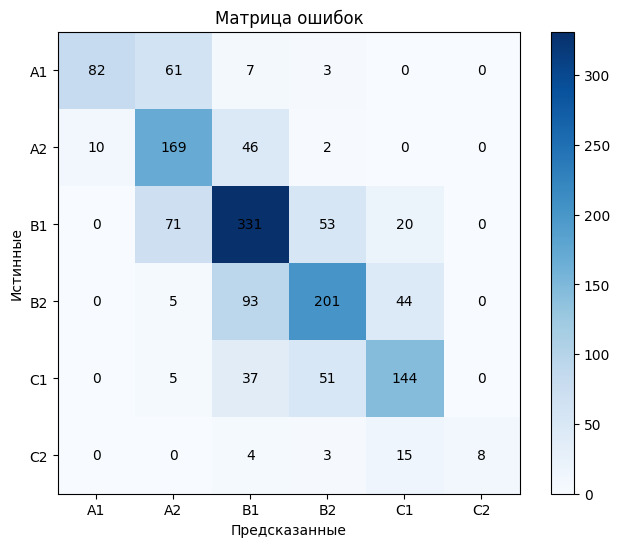

In [57]:
visualize_cm(true_labels, predictions)

## 2

In [58]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*2
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6097
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.943500,0.921854
2,0.570800,0.926883
3,0.137500,1.425667


Обучение завершено за 331.64 секунд (0:05:31)


In [59]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6253
F1 Micro: 0.6253
F1 Macro: 0.6074
F1 Weighted: 0.6250
MAE: 0.4464
              precision    recall  f1-score   support

           1       0.87      0.60      0.71       153
           2       0.55      0.64      0.59       227
           3       0.61      0.71      0.66       475
           4       0.64      0.54      0.58       343
           5       0.61      0.60      0.61       237
           6       0.57      0.43      0.49        30

    accuracy                           0.63      1465
   macro avg       0.64      0.59      0.61      1465
weighted avg       0.64      0.63      0.62      1465



0.6253
0.6253
0.6074
0.6250
0.4464
331.64


In [60]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':2,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

132

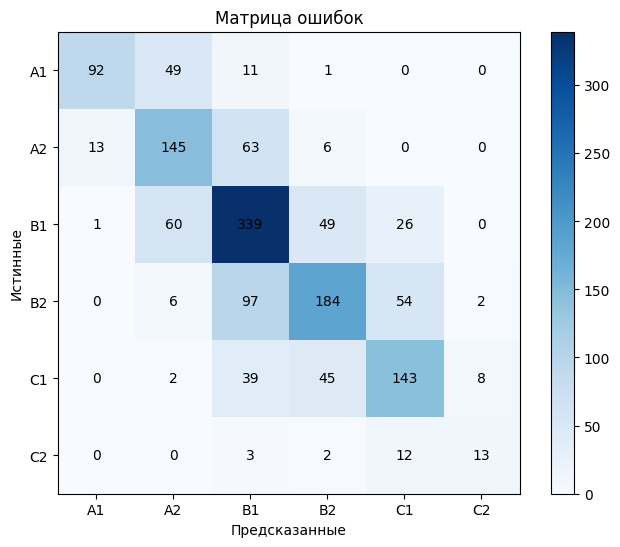

In [61]:
visualize_cm(true_labels, predictions)

## 3

In [62]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*3
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6217
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.939100,0.931676
2,0.454100,0.960423
3,0.141400,1.453315


Обучение завершено за 334.44 секунд (0:05:34)


In [63]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6369
F1 Micro: 0.6369
F1 Macro: 0.5820
F1 Weighted: 0.6322
MAE: 0.4601
              precision    recall  f1-score   support

           1       0.71      0.80      0.75       153
           2       0.63      0.49      0.55       227
           3       0.68      0.66      0.67       475
           4       0.67      0.58      0.62       343
           5       0.52      0.77      0.62       237
           6       0.83      0.17      0.28        30

    accuracy                           0.64      1465
   macro avg       0.67      0.58      0.58      1465
weighted avg       0.65      0.64      0.63      1465



0.6369
0.6369
0.5820
0.6322
0.4601
334.44


In [64]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':3,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

182

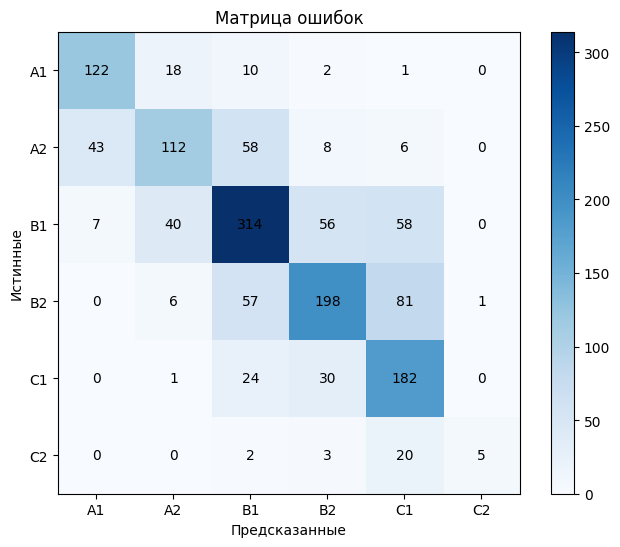

In [65]:
visualize_cm(true_labels, predictions)

## 4

In [66]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*4
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6337
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.936000,0.957651
2,0.493100,1.057797
3,0.196300,1.468199


Обучение завершено за 340.39 секунд (0:05:40)


In [67]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6205
F1 Micro: 0.6205
F1 Macro: 0.5958
F1 Weighted: 0.6180
MAE: 0.4532
              precision    recall  f1-score   support

           1       0.84      0.65      0.73       153
           2       0.59      0.63      0.61       227
           3       0.61      0.70      0.65       475
           4       0.55      0.66      0.60       343
           5       0.74      0.42      0.54       237
           6       0.58      0.37      0.45        30

    accuracy                           0.62      1465
   macro avg       0.65      0.57      0.60      1465
weighted avg       0.64      0.62      0.62      1465



0.6205
0.6205
0.5958
0.6180
0.4532
340.39


In [68]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':4,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

232

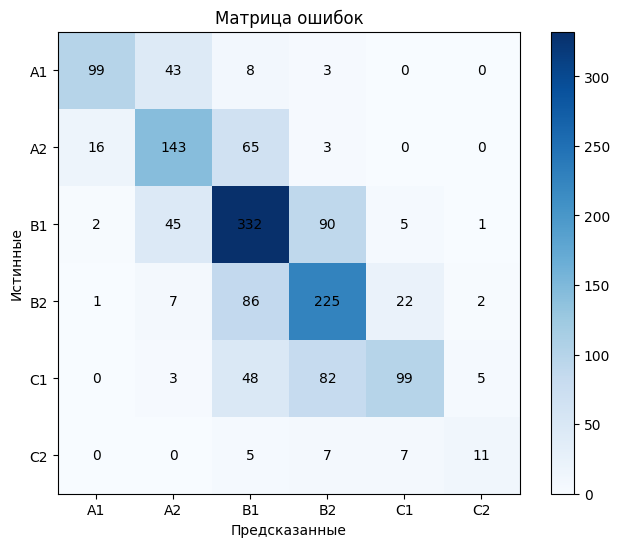

In [69]:
visualize_cm(true_labels, predictions)

## 5

In [70]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*5
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6457
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.904100,0.970505
2,0.482000,1.002745
3,0.179000,1.510382


Обучение завершено за 345.90 секунд (0:05:45)


In [71]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6150
F1 Micro: 0.6150
F1 Macro: 0.5541
F1 Weighted: 0.6038
MAE: 0.4648
              precision    recall  f1-score   support

           1       0.73      0.77      0.75       153
           2       0.65      0.43      0.52       227
           3       0.60      0.73      0.66       475
           4       0.55      0.69      0.61       343
           5       0.70      0.39      0.50       237
           6       0.83      0.17      0.28        30

    accuracy                           0.62      1465
   macro avg       0.68      0.53      0.55      1465
weighted avg       0.63      0.62      0.60      1465



0.6150
0.6150
0.5541
0.6038
0.4648
345.90


In [72]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':5,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

282

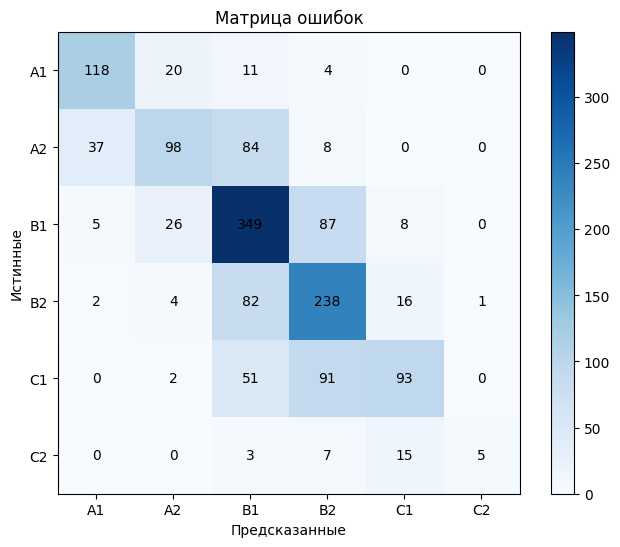

In [73]:
visualize_cm(true_labels, predictions)

## 6

In [10]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*6
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6577
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.914000,0.942178
2,0.457400,0.963137
3,0.162900,1.458728


Обучение завершено за 351.40 секунд (0:05:51)


In [11]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6246
F1 Micro: 0.6246
F1 Macro: 0.6162
F1 Weighted: 0.6123
MAE: 0.4526
              precision    recall  f1-score   support

           1       0.74      0.80      0.77       153
           2       0.65      0.37      0.47       227
           3       0.55      0.85      0.67       475
           4       0.66      0.50      0.57       343
           5       0.74      0.50      0.60       237
           6       0.83      0.50      0.62        30

    accuracy                           0.62      1465
   macro avg       0.70      0.59      0.62      1465
weighted avg       0.65      0.62      0.61      1465



0.6246
0.6246
0.6162
0.6123
0.4526
351.40


In [12]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':6,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

316

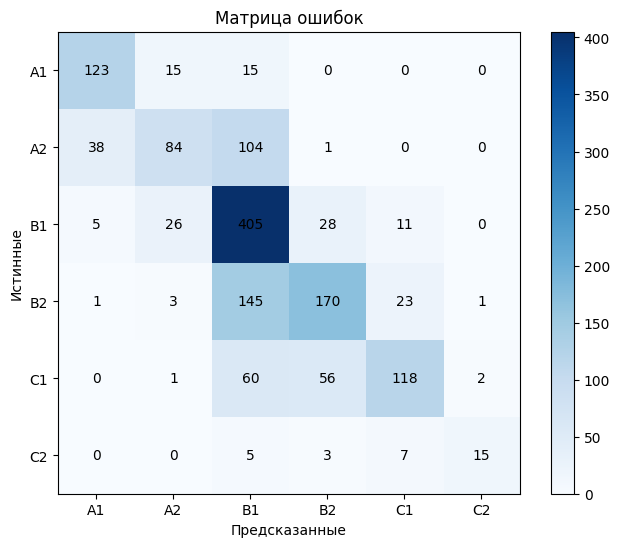

In [13]:
visualize_cm(true_labels, predictions)

## 7

In [14]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*7
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6697
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.848100,0.905265
2,0.447200,0.971960
3,0.105500,1.513548


Обучение завершено за 357.62 секунд (0:05:57)


In [15]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6491
F1 Micro: 0.6491
F1 Macro: 0.6335
F1 Weighted: 0.6464
MAE: 0.4307
              precision    recall  f1-score   support

           1       0.70      0.82      0.75       153
           2       0.61      0.56      0.58       227
           3       0.64      0.71      0.68       475
           4       0.65      0.62      0.64       343
           5       0.64      0.58      0.61       237
           6       0.86      0.40      0.55        30

    accuracy                           0.65      1465
   macro avg       0.68      0.61      0.63      1465
weighted avg       0.65      0.65      0.65      1465



0.6491
0.6491
0.6335
0.6464
0.4307
357.62


In [16]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':7,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

350

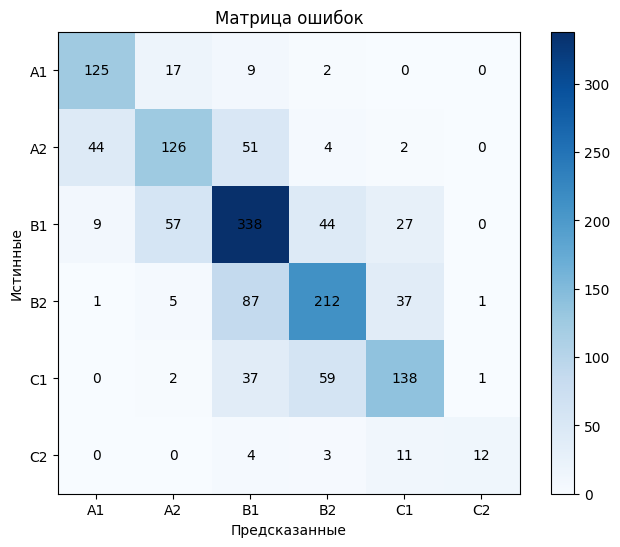

In [17]:
visualize_cm(true_labels, predictions)

## 8

In [18]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*8
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6817
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.829000,0.988925
2,0.426600,1.000263
3,0.104400,1.467148


Обучение завершено за 363.05 секунд (0:06:03)


In [19]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6082
F1 Micro: 0.6082
F1 Macro: 0.5708
F1 Weighted: 0.5936
MAE: 0.4819
              precision    recall  f1-score   support

           1       0.59      0.84      0.69       153
           2       0.60      0.35      0.44       227
           3       0.57      0.79      0.66       475
           4       0.74      0.43      0.54       343
           5       0.63      0.65      0.64       237
           6       0.71      0.33      0.45        30

    accuracy                           0.61      1465
   macro avg       0.64      0.56      0.57      1465
weighted avg       0.63      0.61      0.59      1465



0.6082
0.6082
0.5708
0.5936
0.4819
363.05


In [20]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':8,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

399

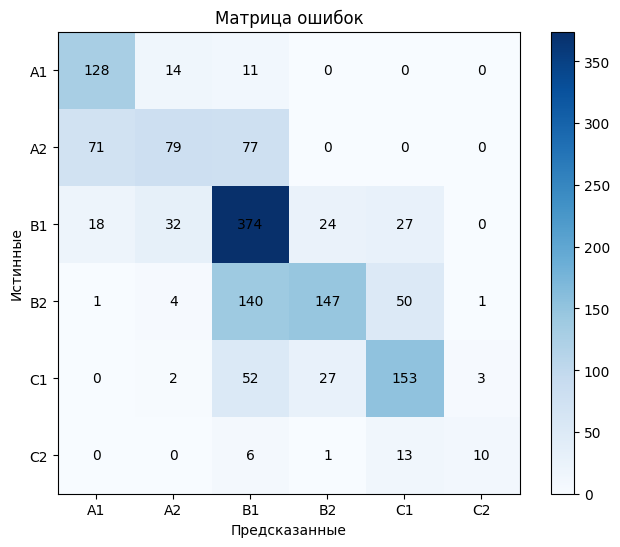

In [21]:
visualize_cm(true_labels, predictions)

## 9

In [22]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*9
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6937
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.792600,1.063840
2,0.427200,1.024578
3,0.116600,1.569310


Обучение завершено за 369.02 секунд (0:06:09)


In [23]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6683
F1 Micro: 0.6683
F1 Macro: 0.6400
F1 Weighted: 0.6670
MAE: 0.4089
              precision    recall  f1-score   support

           1       0.82      0.73      0.77       153
           2       0.58      0.74      0.65       227
           3       0.65      0.72      0.68       475
           4       0.69      0.62      0.65       343
           5       0.72      0.58      0.64       237
           6       0.90      0.30      0.45        30

    accuracy                           0.67      1465
   macro avg       0.72      0.61      0.64      1465
weighted avg       0.68      0.67      0.67      1465



0.6683
0.6683
0.6400
0.6670
0.4089
369.02


In [24]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':9,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

433

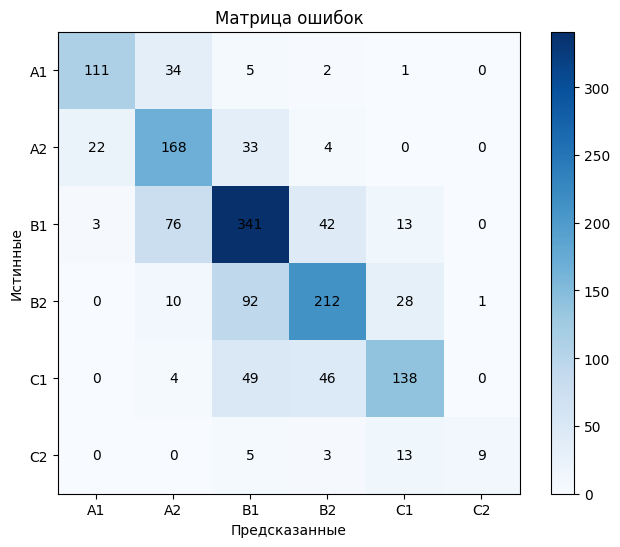

In [25]:
visualize_cm(true_labels, predictions)

## 10

In [29]:
c2 = pd.DataFrame()
c2['augmented-text'] = texts_to_add*10
model, val_dataset, train_time = fit(c2)

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 7057
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.786200,0.919702
2,0.373500,1.006773
3,0.120700,1.541020


Обучение завершено за 377.99 секунд (0:06:17)


In [30]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6314
F1 Micro: 0.6314
F1 Macro: 0.6305
F1 Weighted: 0.6286
MAE: 0.4437
              precision    recall  f1-score   support

           1       0.80      0.70      0.75       153
           2       0.58      0.70      0.63       227
           3       0.60      0.73      0.66       475
           4       0.65      0.49      0.56       343
           5       0.66      0.55      0.60       237
           6       0.93      0.43      0.59        30

    accuracy                           0.63      1465
   macro avg       0.70      0.60      0.63      1465
weighted avg       0.64      0.63      0.63      1465



0.6314
0.6314
0.6305
0.6286
0.4437
377.99


In [31]:
path = Path('res.json')
data = json.loads(path.read_text(encoding='utf-8'))
data.append({'samples':10,'recall_c2':recall_c2})
path.write_text(json.dumps(data), encoding='utf-8')

484

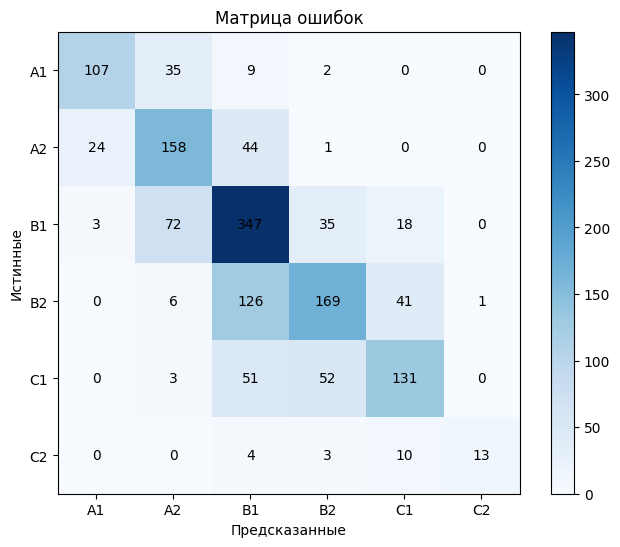

In [32]:
visualize_cm(true_labels, predictions)

## Результаты

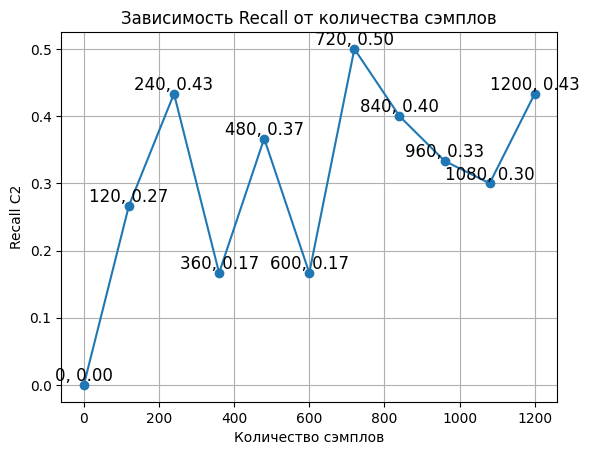

In [33]:
with open('res.json', 'r', encoding='utf-8') as file:
    results = json.load(file)

samples = [i['samples']*120 for i in results]
recalls = [i['recall_c2'] for i in results]

plt.plot(samples, recalls, marker='o')

for i in range(len(samples)):
    plt.text(samples[i], recalls[i], f'{samples[i]}, {recalls[i]:.2f}', 
             fontsize=12, ha='center', va='bottom')
    
plt.xlabel('Количество сэмплов')
plt.ylabel('Recall C2')
plt.title('Зависимость Recall от количества сэмплов')
plt.grid()
plt.show()

# UnderSampling

In [74]:
texts150 = []
labels150 = []

for i in range(1,7):
    df_i = df[df['label'] == i]
    df_i = df_i.reset_index()
    for text in df_i['fragment'][:150]:
        texts150.append(text)
        labels150.append(i)


In [75]:
df_under = pd.DataFrame()
df_under['fragment'] = texts150
df_under['label'] = labels150

In [76]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_under['fragment'].values,
    df_under['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_under['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 720
Размер валидационной выборки без аугментаций: 180


In [77]:
c2 = pd.DataFrame()
c2['augmented-text'] = []
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 720
Валидационная выборка без аугментации: 180


Epoch,Training Loss,Validation Loss
1,No log,1.382642
2,1.631500,1.038181
3,0.943900,0.985413


Обучение завершено за 53.99 секунд (0:00:53)


In [78]:
true_labels, predictions, recall_c2 = predict(model, val_dataset, device, train_time)

Accuracy: 0.6278
F1 Micro: 0.6278
F1 Macro: 0.6280
F1 Weighted: 0.6280
MAE: 0.4778
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        30
           2       0.47      0.60      0.53        30
           3       0.45      0.47      0.46        30
           4       0.75      0.60      0.67        30
           5       0.68      0.50      0.58        30
           6       0.75      0.80      0.77        30

    accuracy                           0.63       180
   macro avg       0.64      0.63      0.63       180
weighted avg       0.64      0.63      0.63       180



0.6278
0.6278
0.6280
0.6280
0.4778
53.99


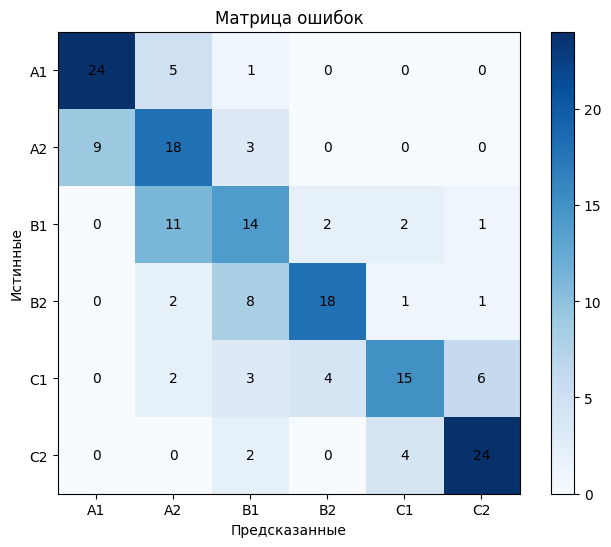

In [79]:
visualize_cm(true_labels, predictions)